<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/Exercise_PCA_Basics_UNSOLVED_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise — Principal Component Analysis (PCA)

**Goal:** Learn the basics of PCA for dimensionality reduction and visualisation using scikit-learn.

**Dataset:** [Palmer Penguins](https://github.com/allisonhorst/palmerpenguins) — body measurements of three penguin species from Antarctica.

**What you will practise:**
1. Standardising data before PCA
2. Fitting PCA and inspecting explained variance
3. Visualising data in 2D principal-component space
4. Choosing the number of components
5. Reconstructing data from fewer components

**Instructions:** Fill in every `___` gap, then run the cells.

---

## 1 · Imports

In [14]:
!pip install -q palmerpenguins

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from palmerpenguins import load_penguins
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)

## 2 · Load and inspect the data

The dataset has 4 numeric measurements per penguin:
**bill length**, **bill depth**, **flipper length**, and **body mass**.

Three species: *Adélie*, *Chinstrap*, *Gentoo*.

**Task 2.1:** Load the penguins dataset, drop rows with missing values, and display the first few rows.

In [15]:
df = load_penguins().dropna()

print(f"Shape: {df.shape}")
df.head()

Shape: (333, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


**Task 2.2:** Print descriptive statistics for only the 4 numeric measurement columns.

In [16]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
df[numeric_cols].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


## 3 · Standardise the features

PCA is sensitive to the scale of the features — body mass is in grams while bill depth is in mm.  
We use `StandardScaler` so each feature has **mean = 0** and **std = 1**.

**Task 3.1:** Create a matrix `X` with the 4 numeric columns and a vector `y` with the species labels.  
Fit a `StandardScaler` and transform `X` into `X_scaled`.

In [17]:
X = df[numeric_cols].values
y = df["species"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean after scaling:  {X_scaled.mean(axis=0).round(2)}")
print(f"Std after scaling:   {X_scaled.std(axis=0).round(2)}")

Mean after scaling:  [-0. -0.  0. -0.]
Std after scaling:   [1. 1. 1. 1.]


## 4 · Fit PCA with all components

First we fit PCA keeping **all 4 components** so we can see how much variance each one explains.

**Task 4.1:** Create a `PCA(n_components=4)` object, fit it on `X_scaled`, and print the explained variance ratio for each component.

In [18]:
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

print("Explained variance ratio per component:")
for i, ratio in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.4f}  ({ratio:.2%})")

print(f"\nTotal: {pca_full.explained_variance_ratio_.sum():.4f}")

Explained variance ratio per component:
  PC1: 0.6863  (68.63%)
  PC2: 0.1945  (19.45%)
  PC3: 0.0922  (9.22%)
  PC4: 0.0270  (2.70%)

Total: 1.0000


**Task 4.2:** Create a bar chart of the explained variance ratio **and** a line showing the cumulative variance.  
Add a horizontal dashed line at the **95 %** threshold.

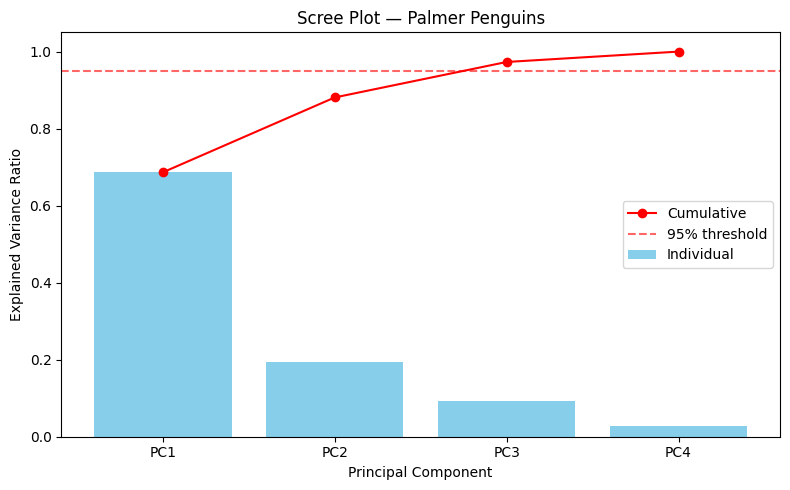

In [28]:
evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

fig, ax = plt.subplots()
x = np.arange(1, len(evr) + 1)

ax.bar(x, evr, color="skyblue", label="Individual")
ax.plot(x, cumulative, "o-", color="red", label="Cumulative")
ax.axhline(y=0.95, color="red", linestyle="--", alpha=0.6, label="95% threshold")

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot — Palmer Penguins")
ax.set_xticks(x)
ax.set_xticklabels([f"PC{i}" for i in x])
ax.legend()
plt.tight_layout()
plt.show()

**Question:** How many components are needed to explain at least **95 %** of the variance?

*Write your answer below.*

In [20]:
# How many components are needed for >=95% variance?
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed for >=95% variance: {n_95}")

Components needed for >=95% variance: 3


## 5 · Visualise in 2D

Project the data onto the first two principal components and colour by species.

**Task 5.1:** Fit a `PCA(n_components=2)` on `X_scaled` and create a 2D scatter plot coloured by species.

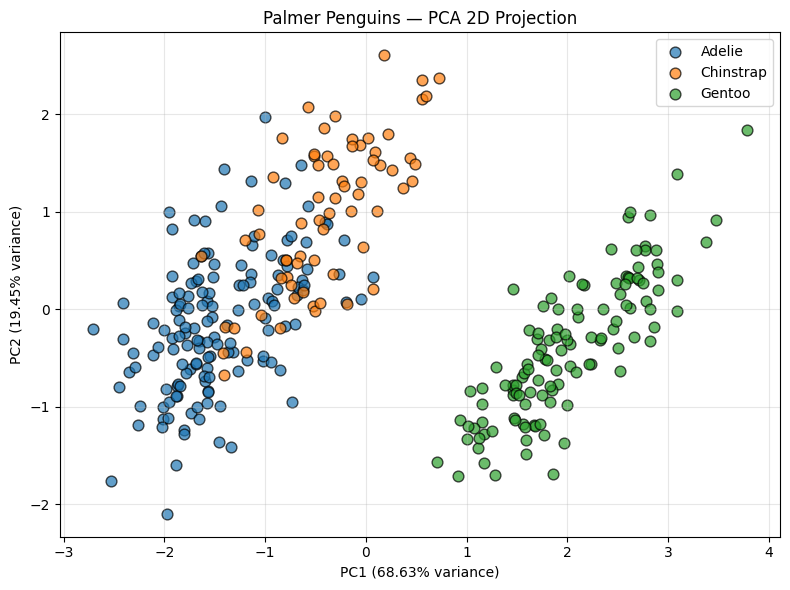

In [21]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
species_list = ["Adelie", "Chinstrap", "Gentoo"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for name, color in zip(species_list, colors):
    mask = y == name
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=name, color=color, alpha=0.7, edgecolors="k", s=60)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)")
plt.title("Palmer Penguins — PCA 2D Projection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Task 5.2:** Which species is the easiest to separate? Which two overlap the most?

*Write your answer below.*

In [22]:
# YOUR ANSWER:
# Which species is easiest to separate?  Gentoo
# Which two species overlap the most?    Adelie and Chinstrap

## 6 · Inspect component loadings

The **loadings** tell us which original features contribute most to each principal component.

**Task 6.1:** Create a DataFrame of the loadings (rows = components, columns = original feature names) and display it.

In [23]:
loadings = pd.DataFrame(
    pca_2d.components_,
    columns=numeric_cols,
    index=["PC1", "PC2"],
)
loadings.round(3)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
PC1,0.454,-0.399,0.577,0.550
PC2,0.600,0.796,0.006,0.076


**Task 6.2:** Create a heatmap of the loadings.

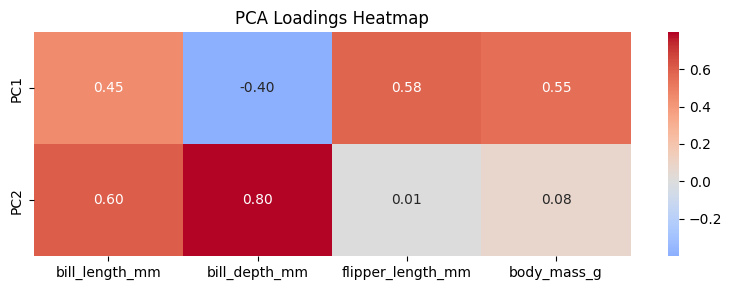

In [24]:
plt.figure(figsize=(8, 3))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("PCA Loadings Heatmap")
plt.tight_layout()
plt.show()

## 7 · Reconstruction from fewer components

When we reduce dimensions we lose some information. The **reconstruction error** measures how much.

**Task 7.1:** Project the data to 2 components and reconstruct it back to the original 4-dimensional space.  
Compute the mean squared error (MSE) between the original scaled data and the reconstruction.

In [25]:
X_reconstructed = pca_2d.inverse_transform(X_2d)

mse = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Reconstruction MSE (2 components): {mse:.4f}")

Reconstruction MSE (2 components): 0.1191


**Task 7.2:** Repeat the reconstruction for 1, 2, 3, and 4 components.  
Plot the MSE versus the number of components.

k=1  MSE=0.3137
k=2  MSE=0.1191
k=3  MSE=0.0270
k=4  MSE=0.0000


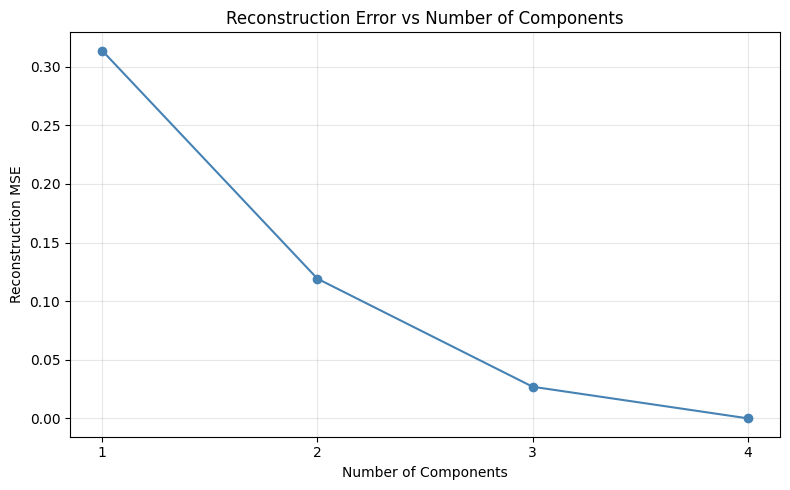

In [26]:
mse_list = []
for k in range(1, 5):
    pca_k = PCA(n_components=k)
    X_k = pca_k.fit_transform(X_scaled)
    X_rec = pca_k.inverse_transform(X_k)
    mse_k = np.mean((X_scaled - X_rec) ** 2)
    mse_list.append(mse_k)
    print(f"k={k}  MSE={mse_k:.4f}")

plt.figure()
plt.plot(range(1, 5), mse_list, "o-", color="steelblue")
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error vs Number of Components")
plt.xticks(range(1, 5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8 · Bonus: PCA on a larger dataset

Apply PCA to the **Wine** dataset (`sklearn.datasets.load_wine`) which has **13 features**.  
Find how many components explain 90 % of the variance and create a 2D scatter plot.

Components for >=90% variance: 8 out of 13


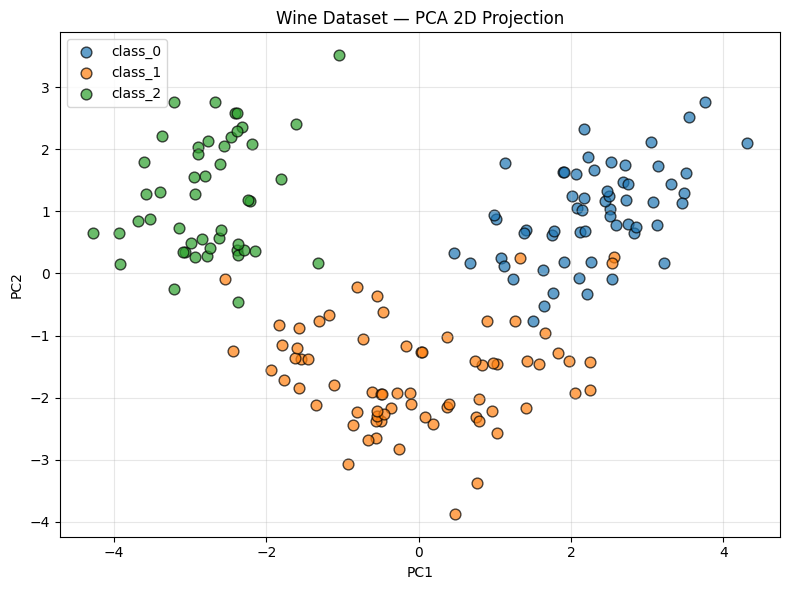

In [27]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)

pca_wine = PCA()
pca_wine.fit(X_wine)

cumvar_wine = np.cumsum(pca_wine.explained_variance_ratio_)
n_90 = np.argmax(cumvar_wine >= 0.90) + 1
print(f"Components for >=90% variance: {n_90} out of {wine.data.shape[1]}")

# 2D scatter
X_wine_2d = PCA(n_components=2).fit_transform(X_wine)

plt.figure(figsize=(8, 6))
for cls in range(3):
    mask = wine.target == cls
    plt.scatter(X_wine_2d[mask, 0], X_wine_2d[mask, 1],
                label=wine.target_names[cls], alpha=0.7, edgecolors="k", s=60)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Dataset — PCA 2D Projection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
**Well done!** You have completed the PCA exercise.

**Key takeaways:**
- Always **standardise** before PCA.
- The **scree plot** helps choose the number of components.
- **Loadings** show which features drive each component.
- **Reconstruction error** quantifies information loss.